In [5]:
# Import necessary libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset (using latin1 encoding to handle special characters)
df = pd.read_csv('online_retail_II.csv', encoding='latin1')

# Display the first 5 rows to understand the data structure
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [2]:
# Check the shape (number of rows and columns) of the raw dataset
print(f"Dataset shape before cleaning: {df.shape}")

# Get a summary of the dataset to identify missing values and data types
df.info()

Dataset shape before cleaning: (47114, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47114 entries, 0 to 47113
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Invoice      47114 non-null  object 
 1   StockCode    47114 non-null  object 
 2   Description  46852 non-null  object 
 3   Quantity     47113 non-null  float64
 4   InvoiceDate  47113 non-null  object 
 5   Price        47113 non-null  float64
 6   Customer ID  33592 non-null  float64
 7   Country      47113 non-null  object 
dtypes: float64(3), object(5)
memory usage: 2.9+ MB


In [6]:
# --- DATA CLEANING PIPELINE ---

# 1. Drop rows where 'Customer ID' is missing (we cannot cluster anonymous users)
df = df.dropna(subset=['Customer ID'])

# 2. Filter out cancelled orders (Quantity <= 0) and invalid prices
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]

# 3. Create a new feature 'TotalAmount' (Quantity * Price) for monetary value
df['TotalAmount'] = df['Quantity'] * df['Price']

# 4. Convert 'InvoiceDate' to datetime object for recency calculation
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Check the final shape after all cleaning steps
print(f"Dataset shape after cleaning: {df.shape}")

Dataset shape after cleaning: (805549, 9)


In [7]:
# --- RFM CALCULATION ---
import datetime as dt

# 1. Define a snapshot date (1 day after the latest transaction in the dataset)
# This acts as 'today' for our recency calculation
snapshot_date = df['InvoiceDate'].max() + dt.timedelta(days=1)

# 2. Group data by Customer ID and calculate Recency, Frequency, and Monetary values
rfm = df.groupby('Customer ID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,  # Recency: days since last purchase
    'Invoice': 'nunique',                                     # Frequency: count of unique invoices
    'TotalAmount': 'sum'                                      # Monetary: total amount spent
}).reset_index()

# 3. Rename the columns to standard RFM names for clarity
rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'Invoice': 'Frequency',
    'TotalAmount': 'Monetary'
}, inplace=True)

# Display the first 5 rows of our new RFM table
rfm.head()

,Customer ID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,5633.32
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


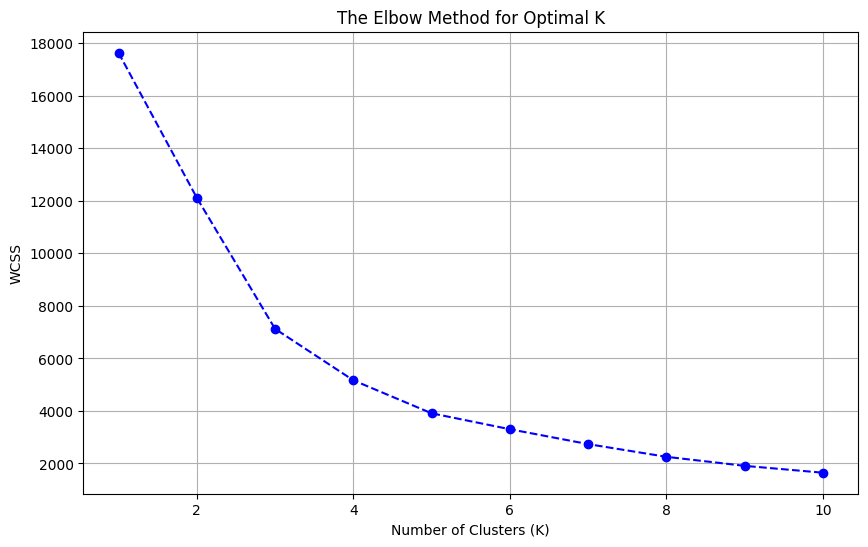

In [8]:
# --- DATA PREPROCESSING FOR K-MEANS ---
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Select only the numerical RFM columns for clustering
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# 2. Standardize the data so all features have equal weight (mean=0, variance=1)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

# Convert scaled data back to a DataFrame for easier handling
rfm_scaled_df = pd.DataFrame(rfm_scaled, columns=rfm_features.columns)

# --- FINDING OPTIMAL 'K' (THE ELBOW METHOD) ---

# Calculate Within-Cluster Sum of Square (WCSS) for different values of k
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--', color='b')
plt.title('The Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

In [9]:
# --- APPLYING K-MEANS WITH K=3 ---

# 1. Initialize and fit the KMeans model
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(rfm_scaled_df)

# 2. Add the assigned cluster labels back to our original RFM table
rfm['Cluster'] = kmeans.labels_

# 3. Profile the clusters: Calculate the average RFM values and count of customers per cluster
cluster_profile = rfm.groupby('Cluster').agg({
    'Recency': 'mean',        # Average days since last purchase
    'Frequency': 'mean',      # Average number of purchases
    'Monetary': 'mean',       # Average total spend
    'Customer ID': 'count'    # Number of customers in this segment
}).round(1)

# Rename the customer count column for better readability
cluster_profile.rename(columns={'Customer ID': 'Num_Customers'}, inplace=True)

# Display the final business profile of our customers
cluster_profile

,Recency,Frequency,Monetary,Num_Customers
Cluster,,,,
0,461.5,2.2,763.1,2012
1,66.1,7.7,3324.2,3848
2,25.4,162.6,189805.1,18


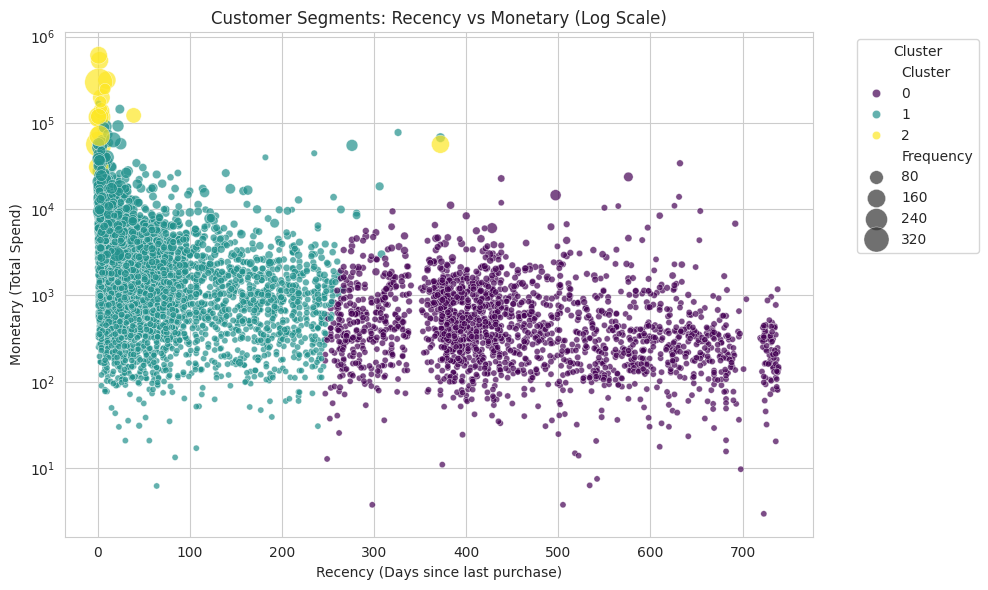

/tmp/ipykernel_2531/1000810719.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=rfm, x='Cluster', palette='viridis')


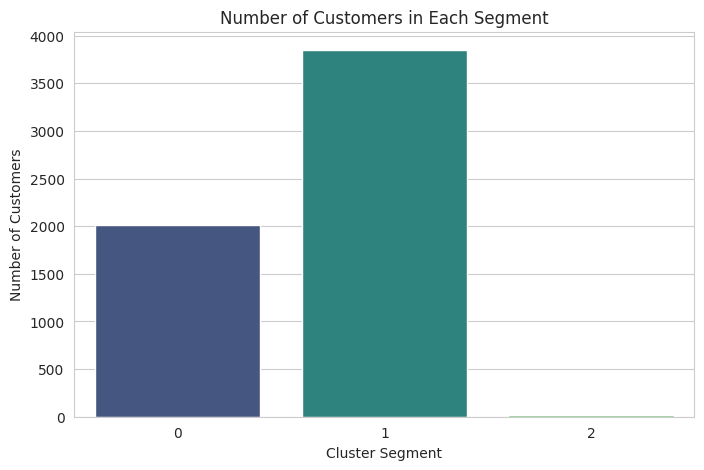

In [10]:
# --- VISUALIZING THE CLUSTERS ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for all plots
sns.set_style("whitegrid")

# 1. Scatter Plot: Recency vs Monetary (Colored by Cluster)
plt.figure(figsize=(10, 6))
# We use log scale for Monetary because the VIPs spent so much they will skew the chart
sns.scatterplot(data=rfm, x='Recency', y='Monetary', hue='Cluster', palette='viridis', size='Frequency', sizes=(20, 400), alpha=0.7)
plt.title('Customer Segments: Recency vs Monetary (Log Scale)')
plt.xlabel('Recency (Days since last purchase)')
plt.ylabel('Monetary (Total Spend)')
plt.yscale('log') # Log scale helps visualize the huge difference in spending
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# 2. Bar Chart: Number of Customers per Cluster
plt.figure(figsize=(8, 5))
sns.countplot(data=rfm, x='Cluster', palette='viridis')
plt.title('Number of Customers in Each Segment')
plt.xlabel('Cluster Segment')
plt.ylabel('Number of Customers')
plt.show()

In [11]:
# Descriptive statistics for the RFM features
rfm[['Recency', 'Frequency', 'Monetary']].describe().round(2)

,Recency,Frequency,Monetary
count,5878.00,5878.00,5878.00
mean,201.33,6.29,3018.62
std,209.34,13.01,14737.73
min,1.00,1.00,2.95
25%,26.00,1.00,348.76
50%,96.00,3.00,898.92
75%,380.00,7.00,2307.09
max,739.00,398.00,608821.65
